LBPH (Local Binary Patterns Histograms)


In [1]:
import os
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt # for displaying images in Jupiter

In [2]:
def display_image(img, title: str = None):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    if len(img.shape) == 3:
        if img.shape[2] == 3:
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_display)
        elif img.shape[2] == 4:
            plt.imshow(img)

    if title:
        plt.title(title)

    plt.axis('off')
    plt.show()

In [3]:
import zipfile
path = 'drive/Datasets/yalefaces.zip'
zip_obj = zipfile.ZipFile(path, 'r')
zip_obj.extractall('./')
zip_obj.close()

In [4]:
print(os.listdir('./yalefaces/train'))

['subject01.noglasses.gif', 'subject10.sleepy.gif', 'subject01.wink.gif', 'subject03.wink.gif', 'subject06.sleepy.gif', 'subject13.centerlight.gif', 'subject10.leftlight.gif', 'subject12.sleepy.gif', 'subject08.sleepy.gif', 'subject05.centerlight.gif', 'subject14.wink.gif', 'subject02.glasses.gif', 'subject03.normal.gif', 'subject11.noglasses.gif', 'subject14.rightlight.gif', 'subject07.sad.gif', 'subject06.wink.gif', 'subject02.happy.gif', 'subject14.leftlight.gif', 'subject09.surprised.gif', 'subject02.noglasses.gif', 'subject13.wink.gif', 'subject04.happy.gif', 'subject07.rightlight.gif', 'subject08.leftlight.gif', 'subject08.happy.gif', 'subject14.centerlight.gif', 'subject13.leftlight.gif', 'subject15.happy.gif', 'subject02.wink.gif', 'subject11.sad.gif', 'subject03.rightlight.gif', 'subject11.sleepy.gif', 'subject12.noglasses.gif', 'subject05.happy.gif', 'subject14.noglasses.gif', 'subject14.glasses.gif', 'subject05.sad.gif', 'subject09.noglasses.gif', 'subject09.leftlight.gif', 

In [5]:
def get_image_data():
    paths = [os.path.join('yalefaces/train', f) for f in os.listdir('./yalefaces/train')]
    # print(paths)

    faces = []
    ids = []
    for path in paths:
        image = Image.open(path).convert('L')
        image_np = np.array(image, 'uint8')

        id = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

        faces.append(image_np)
        ids.append(id)

    return np.array(ids), faces


ids, faces = get_image_data()
len(ids)

135

In [6]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_classifier.train(faces, ids)
lbph_classifier.write('lbph_classifier.yml')

In [11]:
lbph_face_classifier = cv2.face.LBPHFaceRecognizer_create()
lbph_face_classifier.read('lbph_classifier.yml')

In [15]:
test_image = './yalefaces/test/subject10.sad.gif'

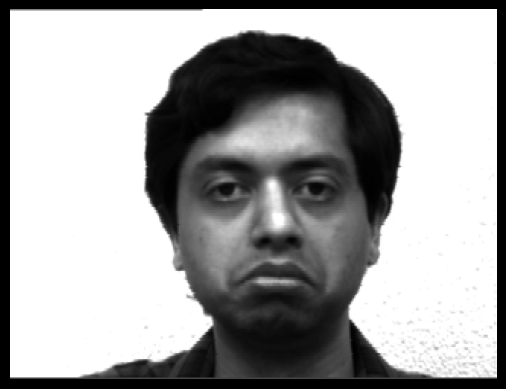

In [21]:
image = Image.open(test_image).convert('L')
image_np = np.array(image, 'uint8')
display_image(image_np)


In [23]:
prediction = lbph_face_classifier.predict(image_np)
prediction

(10, 6.384336460897499)